Saving caseA_ev_events.csv to caseA_ev_events.csv
Saving caseA_smart_home_30min_summer.csv to caseA_smart_home_30min_summer.csv
Main dataset : 1440 timesteps over 30 days
EV events    : 29 days
            timestamp  pv_kw  base_load_kw  import_tariff_gbp_per_kwh  \
0 2025-07-01 00:00:00    0.0        0.6825                     0.1119   
1 2025-07-01 00:30:00    0.0        0.7517                     0.1258   
2 2025-07-01 01:00:00    0.0        0.9220                     0.1163   

   export_price_gbp_per_kwh  ambient_temp_C  
0                    0.0470           14.26  
1                    0.0443           14.03  
2                    0.0491           13.81  

Battery capacity     : 5.0 kWh
Initial SOC          : 2.5 kWh
Policy 2 threshold   : £0.1234/kWh  (60th percentile)

EV energy delivered  : 530.45 kWh
EV energy required   : 530.45 kWh

✓ Both simulations complete.

VERIFICATION: Policy 1 – Greedy Self-Consumption
[PASS] Energy balance | max error = 1.78e-15 kW
[PASS] SOC boun

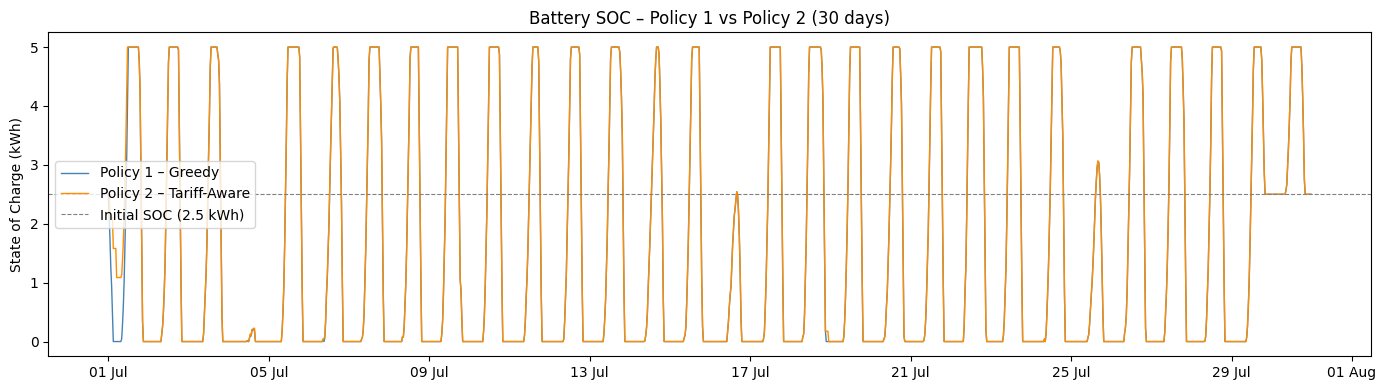

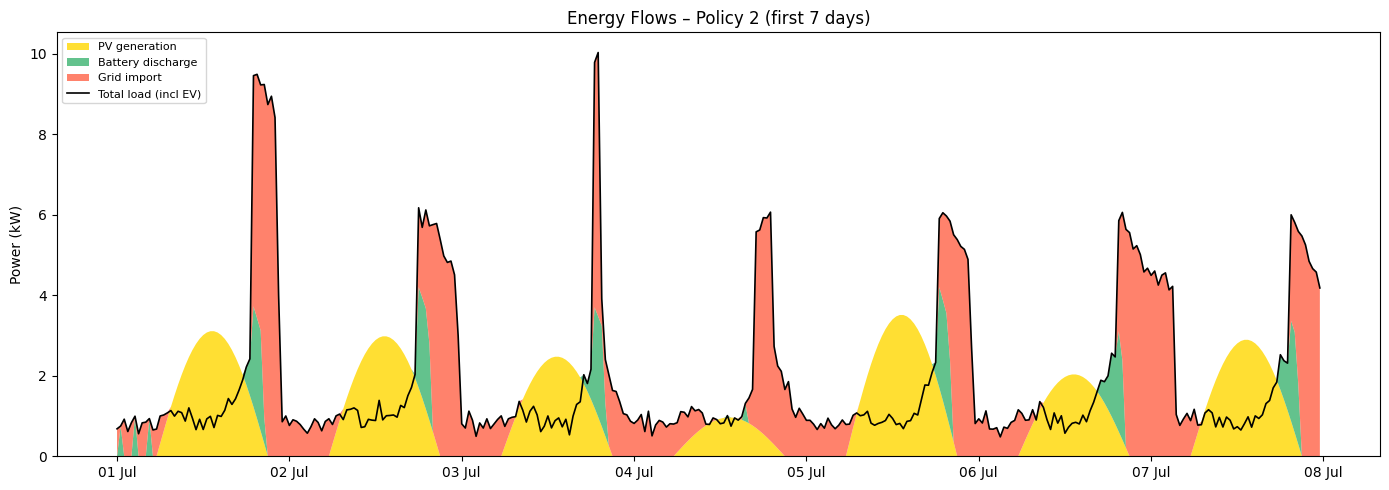

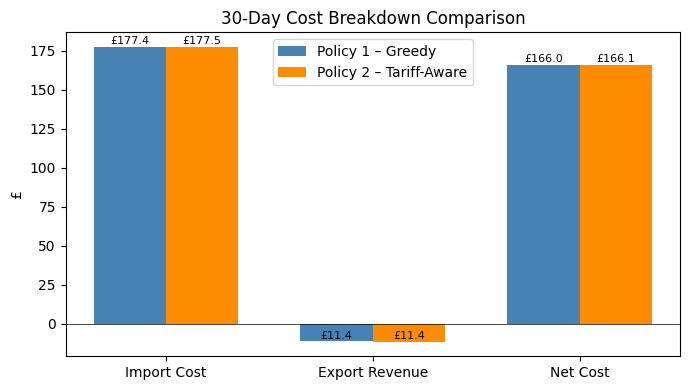

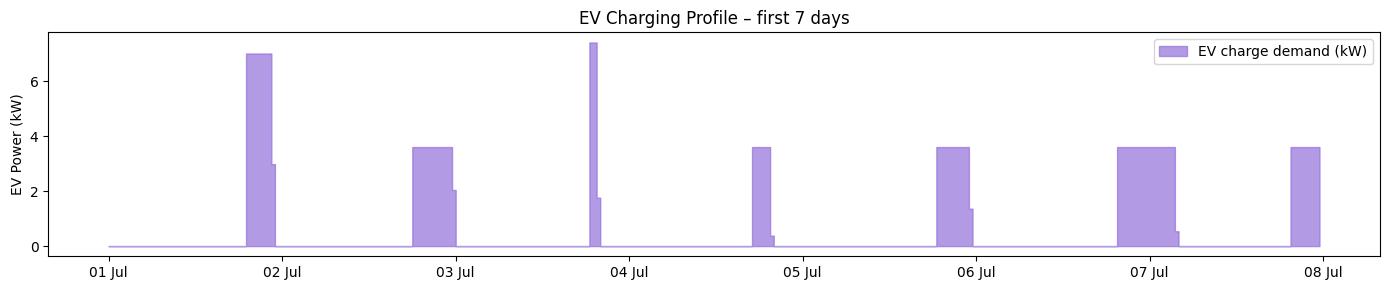

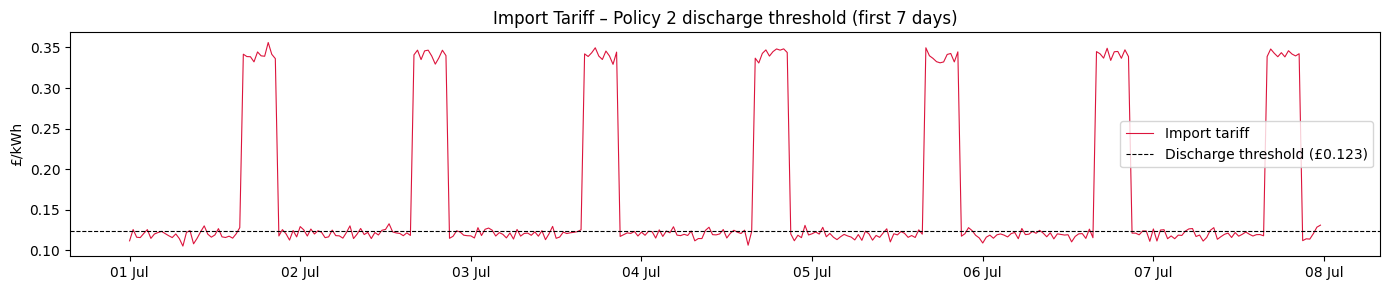


✅ All done. Download the 5 PNG plots for your report.


In [1]:
"""
EGS Coursework – Case A: Smart Home Energy Management (PV + Battery + EV)
==========================================================================
Datasets:
  - caseA_smart_home_30min_summer.csv  (30 days, Δt = 0.5 h)
  - caseA_ev_events.csv                (EV extension – one event per day)

Policies:
  Policy 1 – Self-Consumption         (no tariff awareness)
  Policy 2 – Tariff-Aware             (discharge only during expensive hours)

EV Extension: ASAP charging within each day's parking window.
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # select both CSVs when prompted

df = pd.read_csv('caseA_smart_home_30min_summer.csv', parse_dates=['timestamp'])
ev = pd.read_csv('caseA_ev_events.csv', parse_dates=['arrival_time', 'departure_time'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Main dataset : {len(df)} timesteps over {len(df)//48} days")
print(f"EV events    : {len(ev)} days")
print(df.head(3))

# ── 2. PARAMETERS ─────────────────────────────────────────────────────────────
BAT_CAP   = 5.0          # kWh  usable capacity
P_CH_MAX  = 2.5          # kW   max charge power
P_DIS_MAX = 2.5          # kW   max discharge power
ETA_CH    = 0.95         # –    charge efficiency
ETA_DIS   = 0.95         # –    discharge efficiency
SOC_INIT  = 0.50 * BAT_CAP   # kWh  50% initial SOC
SOC_MIN   = 0.0
SOC_MAX   = BAT_CAP
DT        = 0.5          # h    timestep (30 min)
N         = len(df)

# Policy 2 threshold: discharge battery only when tariff is in top 40%
TARIFF_THRESHOLD = np.percentile(df['import_tariff_gbp_per_kwh'].values, 60)

print(f"\nBattery capacity     : {BAT_CAP} kWh")
print(f"Initial SOC          : {SOC_INIT} kWh")
print(f"Policy 2 threshold   : £{TARIFF_THRESHOLD:.4f}/kWh  (60th percentile)")

# ── 3. EV LOAD BUILDER ────────────────────────────────────────────────────────
# Discretises arrival/departure to nearest 30-min slot.
# ASAP strategy: charge at max power from arrival until energy requirement met.
# P_EV[t] is added to base load BEFORE dispatch — treated as must-meet demand.

def build_ev_load(df, ev):
    ev_load = np.zeros(N)
    for _, row in ev.iterrows():
        arr_idx = int(np.round((row['arrival_time']   - df['timestamp'].iloc[0]).total_seconds() / 1800))
        dep_idx = int(np.round((row['departure_time'] - df['timestamp'].iloc[0]).total_seconds() / 1800))
        arr_idx = max(0, min(arr_idx, N-1))
        dep_idx = max(0, min(dep_idx, N-1))
        if arr_idx >= dep_idx:
            continue
        e_remaining = row['required_energy_kwh']
        p_max       = row['max_charge_power_kw']
        for t in range(arr_idx, dep_idx):
            if e_remaining <= 1e-6:
                break
            p = min(p_max, e_remaining / DT)
            ev_load[t]   = p
            e_remaining -= p * DT
    return ev_load

ev_load    = build_ev_load(df, ev)
total_load = df['base_load_kw'].values + ev_load

print(f"\nEV energy delivered  : {ev_load.sum()*DT:.2f} kWh")
print(f"EV energy required   : {ev['required_energy_kwh'].sum():.2f} kWh")

# ── 4. DISPATCH SIMULATOR ─────────────────────────────────────────────────────
# SOC update equation (applied every timestep):
#   SOC[t+1] = SOC[t] + η_ch · P_ch[t] · Δt  −  P_dis[t] / η_dis · Δt
#
# Energy balance (enforced by construction):
#   PV[t] + P_imp[t] + P_dis[t] = P_load[t] + P_exp[t] + P_ch[t]
#
# Hard constraints (enforced by construction):
#   0 ≤ SOC[t] ≤ 5 kWh
#   0 ≤ P_ch[t] ≤ 2.5 kW,  0 ≤ P_dis[t] ≤ 2.5 kW
#   P_imp[t] ≥ 0,  P_exp[t] ≥ 0
#
# End-of-horizon constraint:
#   SOC[N] ≥ SOC[0]  (enforced by raising soc_floor in last 2 days)

def simulate(policy):
    pv     = df['pv_kw'].values
    tariff = df['import_tariff_gbp_per_kwh'].values
    export = df['export_price_gbp_per_kwh'].values

    soc         = np.zeros(N+1);  soc[0] = SOC_INIT
    p_ch        = np.zeros(N)
    p_dis       = np.zeros(N)
    grid_import = np.zeros(N)
    grid_export = np.zeros(N)
    cost        = np.zeros(N)

    for t in range(N):
        net = pv[t] - total_load[t]          # + = surplus PV,  − = deficit

        # Raise SOC floor in last 96 timesteps (2 days) to enforce end-SOC constraint
        soc_floor = SOC_INIT if t >= (N - 96) else SOC_MIN

        if policy == 'greedy':
            # ── Policy 1: Greedy Self-Consumption ──────────────────────────
            # Surplus → charge battery up to limit, export remainder
            # Deficit → discharge battery up to limit, import remainder
            # No price awareness.
            if net >= 0:
                p_ch[t]        = min(net, P_CH_MAX, (SOC_MAX - soc[t]) / (ETA_CH * DT))
                p_ch[t]        = max(p_ch[t], 0)
                grid_export[t] = net - p_ch[t]
            else:
                deficit        = -net
                max_dis        = max(min(P_DIS_MAX, (soc[t] - soc_floor) * ETA_DIS / DT), 0)
                p_dis[t]       = min(deficit, max_dis)
                grid_import[t] = deficit - p_dis[t]

        elif policy == 'tariff_aware':
            # ── Policy 2: Tariff-Aware ─────────────────────────────────────
            # Charging: identical to Policy 1 — absorb surplus PV, no grid charging.
            # Discharging: ONLY when tariff is in top 40% (expensive hours).
            #   Expensive hour → use battery first, import remainder.
            #   Cheap hour     → import from grid, preserve battery for later.
            # Rationale: shift battery energy toward high-tariff periods to
            # maximise cost avoidance per kWh discharged.
            if net >= 0:
                p_ch[t]        = min(net, P_CH_MAX, (SOC_MAX - soc[t]) / (ETA_CH * DT))
                p_ch[t]        = max(p_ch[t], 0)
                grid_export[t] = net - p_ch[t]
            else:
                deficit  = -net
                max_dis  = max(min(P_DIS_MAX, (soc[t] - soc_floor) * ETA_DIS / DT), 0)
                if tariff[t] >= TARIFF_THRESHOLD:
                    # Expensive hour: drain battery to avoid costly import
                    p_dis[t]       = min(deficit, max_dis)
                    grid_import[t] = deficit - p_dis[t]
                else:
                    # Cheap hour: import freely, save battery for expensive hours
                    grid_import[t] = deficit
                    p_dis[t]       = 0.0

        # SOC update
        soc[t+1] = soc[t] + ETA_CH * p_ch[t] * DT - (p_dis[t] / ETA_DIS) * DT
        soc[t+1] = np.clip(soc[t+1], SOC_MIN, SOC_MAX)

        # Cost (positive = net spend, negative = net revenue)
        cost[t] = (grid_import[t] * tariff[t] - grid_export[t] * export[t]) * DT

    return {'soc': soc, 'p_ch': p_ch, 'p_dis': p_dis,
            'grid_import': grid_import, 'grid_export': grid_export, 'cost': cost}

res1 = simulate('greedy')
res2 = simulate('tariff_aware')
print("\n✓ Both simulations complete.")

# ── 5. VERIFICATION ───────────────────────────────────────────────────────────
# Four explicit checks, each printing PASS or FAIL.

def verify(res, label):
    pv    = df['pv_kw'].values
    soc   = res['soc']
    tol   = 1e-4

    print(f"\n{'='*55}")
    print(f"VERIFICATION: {label}")
    print(f"{'='*55}")

    # Check 1: Per-timestep energy balance
    lhs = pv + res['grid_import'] + res['p_dis']
    rhs = total_load + res['grid_export'] + res['p_ch']
    max_err = np.abs(lhs - rhs).max()
    ok1 = max_err < tol
    print(f"[{'PASS' if ok1 else 'FAIL'}] Energy balance | max error = {max_err:.2e} kW")

    # Check 2: SOC within bounds
    ok2 = (soc >= SOC_MIN - tol).all() and (soc <= SOC_MAX + tol).all()
    print(f"[{'PASS' if ok2 else 'FAIL'}] SOC bounds     | min={soc.min():.3f}, max={soc.max():.3f} kWh  (allowed 0–{SOC_MAX})")

    # Check 3: End-of-horizon SOC ≥ initial SOC
    ok3 = soc[-1] >= SOC_INIT - tol
    print(f"[{'PASS' if ok3 else 'FAIL'}] End SOC ≥ init | final={soc[-1]:.3f} kWh,  init={SOC_INIT:.3f} kWh")

    # Check 4: EV energy delivered = required
    ev_del = ev_load.sum() * DT
    ev_req = ev['required_energy_kwh'].sum()
    ok4 = abs(ev_del - ev_req) < 0.1
    print(f"[{'PASS' if ok4 else 'FAIL'}] EV energy      | delivered={ev_del:.2f} kWh,  required={ev_req:.2f} kWh")

verify(res1, "Policy 1 – Greedy Self-Consumption")
verify(res2, "Policy 2 – Tariff-Aware")

# ── 6. ENERGY & COST BREAKDOWN ────────────────────────────────────────────────
def breakdown(res, label):
    tariff = df['import_tariff_gbp_per_kwh'].values
    export = df['export_price_gbp_per_kwh'].values

    total_import   = res['grid_import'].sum() * DT
    total_export   = res['grid_export'].sum() * DT
    bat_charged    = res['p_ch'].sum() * DT
    bat_discharged = res['p_dis'].sum() * DT
    import_cost    = (res['grid_import'] * tariff * DT).sum()
    export_rev     = (res['grid_export'] * export  * DT).sum()
    net_cost       = import_cost - export_rev

    print(f"\n{'─'*42}")
    print(f"ENERGY & COST BREAKDOWN – {label}")
    print(f"{'─'*42}")
    print(f"  PV generated         : {df['pv_kw'].values.sum()*DT:.1f} kWh")
    print(f"  Total load (incl EV) : {total_load.sum()*DT:.1f} kWh")
    print(f"  Grid import          : {total_import:.1f} kWh")
    print(f"  Grid export          : {total_export:.1f} kWh")
    print(f"  Battery charged      : {bat_charged:.1f} kWh")
    print(f"  Battery discharged   : {bat_discharged:.1f} kWh")
    print(f"  Import cost          : £{import_cost:.2f}")
    print(f"  Export revenue       : £{export_rev:.2f}")
    print(f"  Net cost             : £{net_cost:.2f}")
    return import_cost, export_rev, net_cost

ic1, er1, nc1 = breakdown(res1, "Policy 1 – Greedy")
ic2, er2, nc2 = breakdown(res2, "Policy 2 – Tariff-Aware")
print(f"\n★ Policy 2 net cost vs Policy 1: £{nc2:.2f} vs £{nc1:.2f}  (Δ = £{nc1-nc2:.2f})")

# ── 7. PLOTS ──────────────────────────────────────────────────────────────────
week = slice(0, 48*7)
t_w  = df['timestamp'].iloc[week]

# Plot A: SOC comparison (full 30 days)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], res1['soc'][:-1], label='Policy 1 – Greedy',       lw=1, color='steelblue')
ax.plot(df['timestamp'], res2['soc'][:-1], label='Policy 2 – Tariff-Aware', lw=1, color='darkorange')
ax.axhline(SOC_INIT, ls='--', color='grey', lw=0.8, label=f'Initial SOC ({SOC_INIT} kWh)')
ax.set_ylabel('State of Charge (kWh)')
ax.set_title('Battery SOC – Policy 1 vs Policy 2 (30 days)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.savefig('plot_soc_comparison.png', dpi=150); plt.show()

# Plot B: Energy flows – Policy 2, first 7 days
fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(t_w,
    df['pv_kw'].iloc[week], res2['p_dis'][week], res2['grid_import'][week],
    labels=['PV generation', 'Battery discharge', 'Grid import'],
    colors=['gold', 'mediumseagreen', 'tomato'], alpha=0.8)
ax.plot(t_w, total_load[week], color='black', lw=1.2, label='Total load (incl EV)')
ax.set_ylabel('Power (kW)'); ax.set_title('Energy Flows – Policy 2 (first 7 days)')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.savefig('plot_energy_flows_week1.png', dpi=150); plt.show()

# Plot C: Cost bar chart
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Import Cost', 'Export Revenue', 'Net Cost']
p1_vals = [ic1, -er1, nc1]
p2_vals = [ic2, -er2, nc2]
x = np.arange(3); w = 0.35
bars1 = ax.bar(x - w/2, p1_vals, w, label='Policy 1 – Greedy',       color='steelblue')
bars2 = ax.bar(x + w/2, p2_vals, w, label='Policy 2 – Tariff-Aware', color='darkorange')
ax.set_ylabel('£'); ax.set_title('30-Day Cost Breakdown Comparison')
ax.set_xticks(x); ax.set_xticklabels(categories); ax.legend(); ax.axhline(0, color='black', lw=0.5)
for bar in list(bars1)+list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'£{abs(h):.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.savefig('plot_cost_comparison.png', dpi=150); plt.show()

# Plot D: EV charging profile (first 7 days)
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(t_w, ev_load[week], step='post', alpha=0.7, color='mediumpurple', label='EV charge demand (kW)')
ax.set_ylabel('EV Power (kW)'); ax.set_title('EV Charging Profile – first 7 days')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.savefig('plot_ev_profile.png', dpi=150); plt.show()

# Plot E: Import tariff with threshold line (first 7 days)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_w, df['import_tariff_gbp_per_kwh'].iloc[week], color='crimson', lw=0.8, label='Import tariff')
ax.axhline(TARIFF_THRESHOLD, ls='--', color='black', lw=0.8, label=f'Discharge threshold (£{TARIFF_THRESHOLD:.3f})')
ax.set_ylabel('£/kWh'); ax.set_title('Import Tariff – Policy 2 discharge threshold (first 7 days)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.savefig('plot_tariff.png', dpi=150); plt.show()

print("\n✅ All done. Download the 5 PNG plots for your report.")